# eph_01 — Monovariate RT encoding

Does reaction time predict spike count?

**Pipeline:**
1. Data loading via `data_loading.py`
2. Trial × unit table via `ephys_utils.build_all_counts_df`
3. `AnalysisSpec` + `fit_encoding` — OLS and Spearman, filtering external
4. `PerUnitStatsRegistry` — standard output for downstream spatial / comparison notebooks
5. Diagnostics: T distributions, RT window sweep, population tuning curve, early vs late


## 1. Setup

In [1]:
%matplotlib inline

import contextlib, io, itertools, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess

from plotstyle import apply_style, PALETTE, OKABE_ITO, style_ax, save_fig
apply_style()

In [2]:
# ── Environment detection ─────────────────────────────────────────────────
from pathlib import Path

if Path("/root/capsule").exists():
    ENV       = "codeocean"
    SCRATCH   = Path("/root/capsule/scratch")
    DATA_ROOT = Path("/root/capsule/data")
    FOR_LOCAL = SCRATCH / "for_local"
    MESH_PATH = DATA_ROOT / "LC_percentile_meshes/new_core_mesh.obj"
else:
    ENV       = "local"
    FOR_LOCAL = Path("/Users/mib/Documents/Code/kinematics_analysis/data/for_local")
    DATA_ROOT = FOR_LOCAL
    SCRATCH   = FOR_LOCAL.parent
    MESH_PATH = FOR_LOCAL / "new_core_mesh.obj"

FIG_DIR  = SCRATCH / "figures" / "eph_01_rt_encoding"
SAVE_FIG = False

print(f"ENV       : {ENV}")
print(f"FOR_LOCAL : {FOR_LOCAL}")

ENV       : local
FOR_LOCAL : /Users/mib/Documents/Code/kinematics_analysis/data/for_local


## 2. Data loading

In [3]:
from data_loading import (
    load_session_quality_filter,
    filter_ephys_units,
    load_units_with_spike_times,
)

if ENV == "codeocean":
    base_dirs = [SCRATCH / "session_analysis_mlk"]
    filtered_session_paths = load_session_quality_filter(base_dirs)

    with open(SCRATCH / "combined_unit_tbl.pkl", "rb") as f:
        combined_ephys_data = pickle.load(f)
    filtered_ephys = filter_ephys_units(combined_ephys_data, filtered_session_paths)

    ROOT_SCRATCH = str(DATA_ROOT / "LC-NE_scratch_data_1")
    units_with_spikes = load_units_with_spike_times(filtered_ephys, ROOT_SCRATCH)
else:
    # Local dev: load saved intermediates
    filtered_ephys    = pd.read_pickle(FOR_LOCAL / "filtered_ephys.pkl")
    units_with_spikes = None   # not needed locally; all_counts_df loaded below
    base_dirs         = [FOR_LOCAL]
    print(f"Local dev: filtered_ephys {filtered_ephys.shape}")

Local dev: filtered_ephys (104, 43)


## 3. Build trial × unit table (all_counts_df)

In [4]:
from ephys_utils import AnalysisConfig, build_all_counts_df

cfg = AnalysisConfig(
    align_key="goCue",
    count_window_s=(0.0, 0.2),        # 0–200 ms post-cue response window
    baseline_window_s=(-1.0, 0.0),    # -1 to 0 s pre-cue baseline
    min_trials_per_group=20,
)

if ENV == "codeocean":
    all_counts_df = build_all_counts_df(units_with_spikes, cfg, base_dirs)
else:
    all_counts_df = pd.read_parquet(FOR_LOCAL / "all_counts_df.parquet")

print("all_counts_df shape :", all_counts_df.shape)
print("Columns             :", all_counts_df.columns.tolist())

all_counts_df shape : (31993, 29)
Columns             : ['trial', 'unit_id', 'session', 'spike_count', 'spike_rate_hz', 'baseline_spike_count', 'baseline_spike_rate_hz', 'first_spike_latency_s', 'cue_response_movement_number', 'reaction_time_firstmove', 'reaction_time_cueresponse', 'first_move_peak_velocity', 'first_move_duration', 'first_move_excursion_angle_deg', 'first_move_endpoint_x', 'first_move_endpoint_y', 'first_move_out_duration', 'first_move_out_peak_velocity', 'first_move_out_mean_velocity', 'first_move_out_total_distance', 'cue_response_peak_velocity', 'cue_response_duration', 'cue_response_excursion_angle_deg', 'cue_response_endpoint_x', 'cue_response_endpoint_y', 'cue_response_out_duration', 'cue_response_out_peak_velocity', 'cue_response_out_mean_velocity', 'cue_response_out_total_distance']


## 4. Analysis specifications

Each `AnalysisSpec` captures the full provenance of one analysis:
predictor, response, method, trial filter, and transform.
Trial filtering is applied here — the OLS / Spearman functions receive
an already-filtered DataFrame and do no internal filtering themselves.

In [5]:
from encoding_methods import AnalysisSpec, AnalysisResult, fit_encoding
from encoding_plots import (
    tstat_hist, t_scatter, annotated_heatmap,
    tuning_band, sign_contingency, rt_distribution,
)

# Default RT trial filter: exclude sub-50 ms (anticipatory) and >1 s (inattentive)
RT_QUERY = "reaction_time_firstmove > 0.05 and reaction_time_firstmove < 1.0"

specs = [
    AnalysisSpec(
        name="ols_rt_response",
        predictor_col="reaction_time_firstmove",
        response_col="spike_count",
        method="ols",
        trial_query=RT_QUERY,
        log_x=True, zscore_x=True,
        notes="Primary: log(RT) z-scored -> spike_count, 0-200 ms response window",
    ),
    AnalysisSpec(
        name="ols_rt_baseline",
        predictor_col="reaction_time_firstmove",
        response_col="baseline_spike_count",
        method="ols",
        trial_query=RT_QUERY,
        log_x=True, zscore_x=True,
        notes="Control: same predictor in baseline window (-1 to 0 s)",
    ),
    AnalysisSpec(
        name="spearman_rt_response",
        predictor_col="reaction_time_firstmove",
        response_col="spike_count",
        method="spearman",
        trial_query=RT_QUERY,
        notes="Spearman cross-check for OLS",
    ),
]


## 5. Run encoding analyses

In [6]:
results = {}
for spec in specs:
    results[spec.name] = fit_encoding(all_counts_df, spec)

[ols_rt_response] 103 units, 103 valid, sig: +22 / -16 (FDR α=0.05)


[ols_rt_baseline] 103 units, 103 valid, sig: +19 / -9 (FDR α=0.05)


[spearman_rt_response] 103 units, 103 valid, sig: +21 / -15 (FDR α=0.05)


## 6. Register results

`PerUnitStatsRegistry` is the shared output format. Downstream notebooks
(spatial, behavioral comparison) load from here rather than re-running
the fits.

In [7]:
from per_unit_stats_registry import PerUnitStatsRegistry
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import get_session_prefix

reg = PerUnitStatsRegistry(get_session_prefix=get_session_prefix, alpha=0.05)

for spec in specs:
    reg.register(results[spec.name])

print(reg)


PerUnitStatsRegistry (3 entries):
  ols_rt_baseline                           n= 103  sig=  28  source=regression
  ols_rt_response                           n= 103  sig=  38  source=regression
  spearman_rt_response                      n= 103  sig=  36  source=regression


## 7. Population T-stat distributions

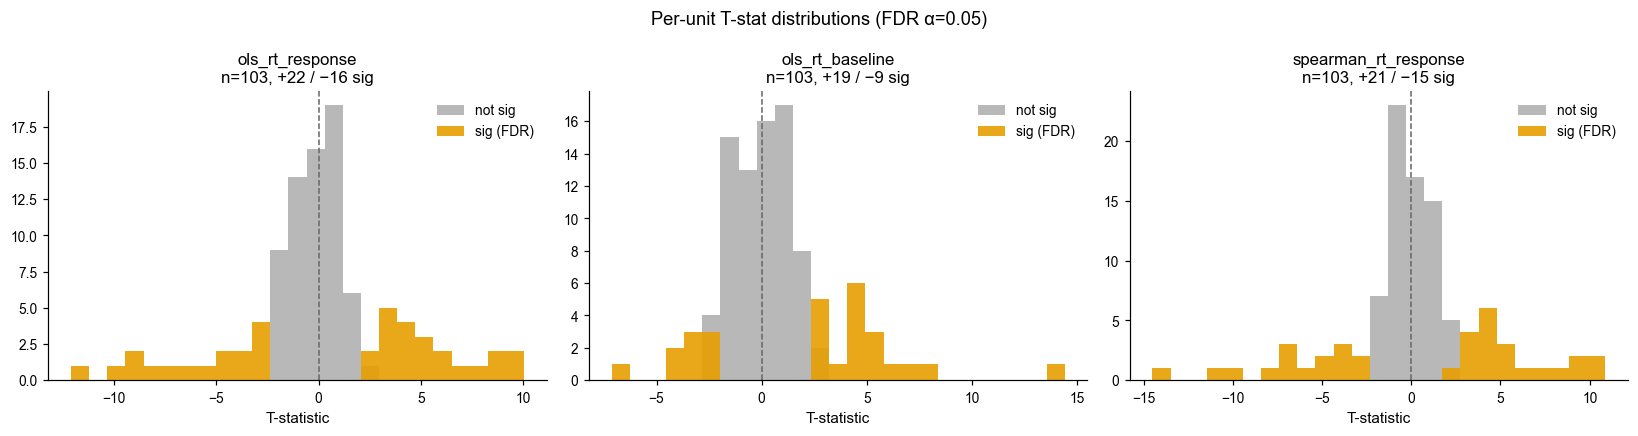

In [8]:
fig, axes = plt.subplots(1, len(specs), figsize=(5 * len(specs), 4), sharey=False)
for ax, spec in zip(axes, specs):
    tstat_hist(results[spec.name].stats, name=spec.name, ax=ax)
fig.suptitle("Per-unit T-stat distributions (FDR α=0.05)")
plt.tight_layout()
save_fig(fig, "tstat_histograms", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

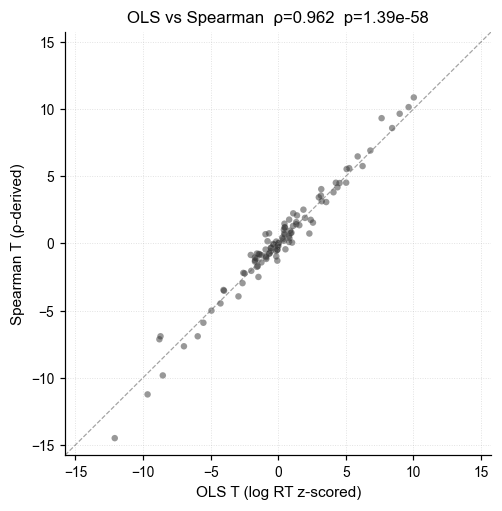

In [9]:
from scipy.stats import spearmanr as _spearmanr

r_ols = results["ols_rt_response"].stats.set_index(["session_prefix", "unit"])["T"]
r_sp  = results["spearman_rt_response"].stats.set_index(["session_prefix", "unit"])["T"]
merged = r_ols.rename("T_ols").to_frame().join(r_sp.rename("T_spearman"), how="inner").dropna()
rho, p = _spearmanr(merged["T_ols"], merged["T_spearman"])

fig, ax = t_scatter(
    merged["T_ols"], merged["T_spearman"],
    xlabel="OLS T (log RT z-scored)", ylabel="Spearman T (ρ-derived)",
    title=f"OLS vs Spearman  ρ={rho:.3f}  p={p:.2e}",
)
save_fig(fig, "ols_vs_spearman", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 8. RT window parameter sweep

Sweep rt_min × rt_max to test how sensitive encoding prevalence is to
the RT range included. Positive and negative encoding tracked separately
so that loss of units (trial count dropout) is distinguishable from
genuine loss of encoding.

In [10]:
RT_MINS = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]
RT_MAXS = [0.30, 0.40, 0.50, 0.60, 0.80, 1.00]

sweep_rows = []
for rt_min, rt_max in itertools.product(RT_MINS, RT_MAXS):
    if rt_min >= rt_max:
        continue
    sweep_spec = AnalysisSpec(
        name=f"sweep",
        predictor_col="reaction_time_firstmove",
        response_col="spike_count",
        method="ols",
        trial_query=f"reaction_time_firstmove >= {rt_min} and reaction_time_firstmove <= {rt_max}",
        log_x=True, zscore_x=True,
    )
    with contextlib.redirect_stdout(io.StringIO()):
        res = fit_encoding(all_counts_df, sweep_spec)
    r = res.stats
    valid   = r["T"].notna()
    sig     = valid & (r["q"] < 0.05)
    pos_sig = sig & (r["coef"] > 0)
    neg_sig = sig & (r["coef"] < 0)
    n_valid = int(valid.sum())
    n_pos   = int(pos_sig.sum())
    n_neg   = int(neg_sig.sum())
    sweep_rows.append({
        "rt_min": rt_min, "rt_max": rt_max,
        "n_valid":       n_valid,
        "pct_pos_sig":   100 * n_pos / n_valid if n_valid else np.nan,
        "pct_neg_sig":   100 * n_neg / n_valid if n_valid else np.nan,
        "mean_T_pos_sig": float(r.loc[pos_sig, "T"].mean()) if n_pos else np.nan,
        "mean_T_neg_sig": float(r.loc[neg_sig, "T"].mean()) if n_neg else np.nan,
    })
    print(f"rt=[{rt_min:.2f}, {rt_max:.2f}]  valid={n_valid}  "
          f"+{n_pos}({100*n_pos/n_valid if n_valid else 0:.0f}%)  "
          f"-{n_neg}({100*n_neg/n_valid if n_valid else 0:.0f}%)")

sweep_df = pd.DataFrame(sweep_rows)


rt=[0.05, 0.30]  valid=103  +4(4%)  -18(17%)


rt=[0.05, 0.40]  valid=103  +6(6%)  -16(16%)


rt=[0.05, 0.50]  valid=103  +12(12%)  -14(14%)


rt=[0.05, 0.60]  valid=103  +21(20%)  -16(16%)


rt=[0.05, 0.80]  valid=103  +22(21%)  -16(16%)


...

rt=[0.15, 0.60]  valid=88  +10(11%)  -1(1%)
rt=[0.15, 0.80]  valid=88  +15(17%)  -4(5%)


rt=[0.15, 1.00]  valid=88  +15(17%)  -3(3%)
rt=[0.20, 0.30]  valid=61  +0(0%)  -0(0%)


rt=[0.20, 0.40]  valid=74  +0(0%)  -0(0%)
rt=[0.20, 0.50]  valid=84  +1(1%)  -0(0%)


rt=[0.20, 0.60]  valid=84  +9(11%)  -0(0%)
rt=[0.20, 0.80]  valid=84  +11(13%)  -0(0%)


rt=[0.20, 1.00]  valid=84  +11(13%)  -0(0%)


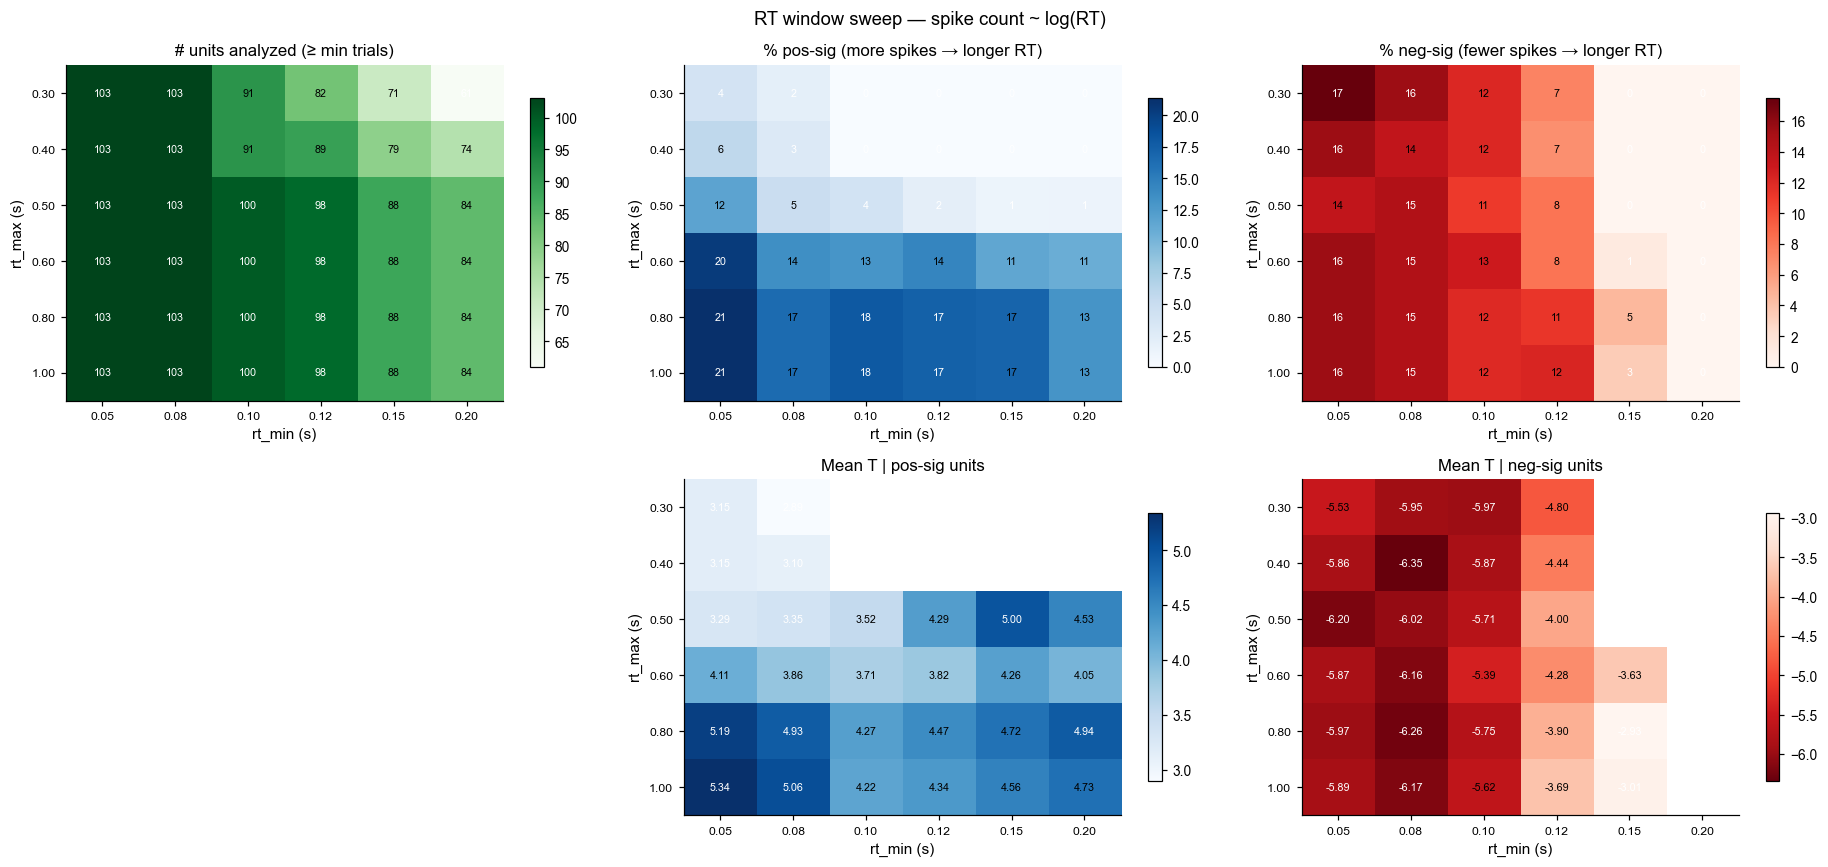

In [11]:
def pivot_sweep(df, col):
    return df.pivot(index="rt_max", columns="rt_min", values=col)

panels = [
    ("n_valid",        "# units analyzed (≥ min trials)", "Greens", "{:.0f}"),
    ("pct_pos_sig",    "% pos-sig (more spikes → longer RT)", "Blues",  "{:.0f}"),
    ("pct_neg_sig",    "% neg-sig (fewer spikes → longer RT)", "Reds",   "{:.0f}"),
    (None,             "",                                     None,     ""),
    ("mean_T_pos_sig", "Mean T | pos-sig units",              "Blues",  "{:.2f}"),
    ("mean_T_neg_sig", "Mean T | neg-sig units",              "Reds_r", "{:.2f}"),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, (col, title, cmap, fmt) in zip(axes.flat, panels):
    if col is None:
        ax.set_visible(False)
        continue
    mat = pivot_sweep(sweep_df, col)
    annotated_heatmap(
        mat.values,
        [f"{v:.2f}" for v in mat.index],
        [f"{v:.2f}" for v in mat.columns],
        cmap=cmap, title=title, xlabel="rt_min (s)", ylabel="rt_max (s)",
        fmt=fmt, ax=ax,
    )

fig.suptitle("RT window sweep — spike count ~ log(RT)")
fig.tight_layout()
save_fig(fig, "rt_sweep", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 8b. RT distribution: log-normality and mixture structure

The window sweep shows that encoding prevalence differs across RT ranges.
Before fixing early/late windows, we ask whether the RT distribution itself
provides evidence of qualitatively distinct behavioral modes (e.g. bimodality
in log space) that would independently justify a window split.


log(RT) distribution  (n=10,436 trials)
  Mean RT : 134.4 ms
  Skewness: 0.889   Excess kurtosis: 0.196
  D'Agostino-Pearson normality: stat=1046.93  p=4.594e-228
  → log(RT) departs from log-normal (right-skewed tail)



  Mixture BIC — 1-component: 18328  2-component: 15982
  ΔBIC (1→2): 2346.5  (>10 favors 2-component, i.e. bimodal)
  Component 1: 98 ms  weight=0.68
  Component 2: 260 ms  weight=0.32


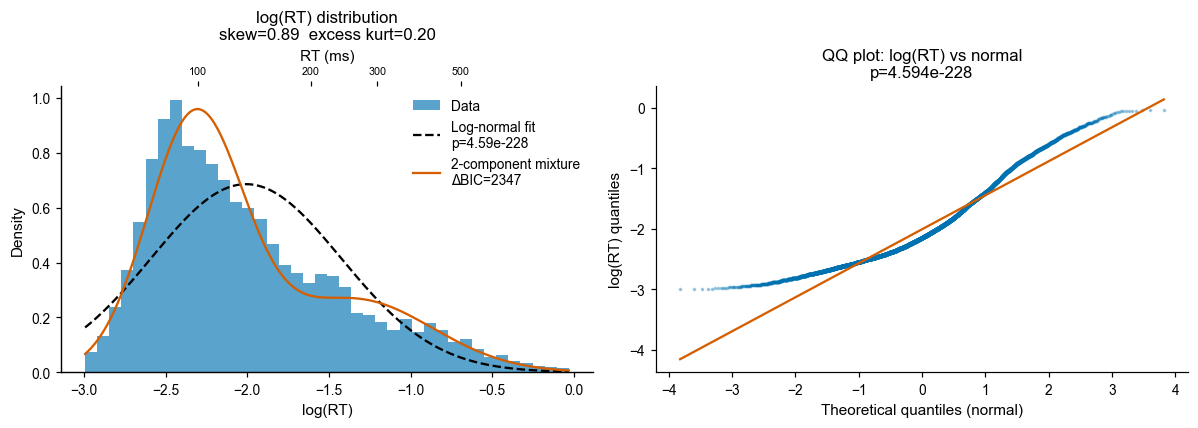

In [12]:
from scipy.stats import normaltest, skew, kurtosis

# Trial-level RTs (deduplicated — one RT per trial, not per unit)
rt_vals = (
    all_counts_df
    .drop_duplicates(subset=["session", "trial"])
    .dropna(subset=["reaction_time_firstmove"])
    .query("reaction_time_firstmove > 0.05 and reaction_time_firstmove < 1.0")
    ["reaction_time_firstmove"]
    .values
)
log_rt = np.log(rt_vals)

stat_da, p_da = normaltest(log_rt)
sk = skew(log_rt)
ku = kurtosis(log_rt)

print(f"log(RT) distribution  (n={len(log_rt):,} trials)")
print(f"  Mean RT : {np.exp(log_rt.mean())*1000:.1f} ms")
print(f"  Skewness: {sk:.3f}   Excess kurtosis: {ku:.3f}")
print(f"  D'Agostino-Pearson normality: stat={stat_da:.2f}  p={p_da:.3e}")
if p_da < 0.05:
    print(f"  → log(RT) departs from log-normal", end="")
    print(f" (right-skewed tail)" if sk > 0 else " (left-skewed tail)")
else:
    print(f"  → log(RT) consistent with log-normal")

# Gaussian mixture model: 1-component vs 2-component
try:
    from sklearn.mixture import GaussianMixture
    X = log_rt.reshape(-1, 1)
    gm1 = GaussianMixture(n_components=1, random_state=42).fit(X)
    gm2 = GaussianMixture(n_components=2, random_state=42).fit(X)
    delta_bic = gm1.bic(X) - gm2.bic(X)
    print(f"\n  Mixture BIC — 1-component: {gm1.bic(X):.0f}  2-component: {gm2.bic(X):.0f}")
    print(f"  ΔBIC (1→2): {delta_bic:.1f}  (>10 favors 2-component, i.e. bimodal)")
    if delta_bic > 10:
        ord_idx = np.argsort(gm2.means_.ravel())
        for k, i in enumerate(ord_idx):
            m = np.exp(gm2.means_[i, 0]) * 1000
            w = gm2.weights_[i]
            print(f"  Component {k+1}: {m:.0f} ms  weight={w:.2f}")
    has_gm = True
except ImportError:
    has_gm = False
    delta_bic = None
    gm2 = None
    print("  sklearn not available — skipping mixture model")

fig, axes = rt_distribution(
    log_rt, p_da=p_da, sk=sk, ku=ku,
    gm2=gm2 if has_gm else None,
    delta_bic=delta_bic,
)
save_fig(fig, "rt_distribution", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 9. Population tuning curve

E[spike_count | log-RT bin], z-scored per unit, split by OLS significance group.
Shows whether pos-sig and neg-sig classifications reflect genuinely different
population-level tuning.

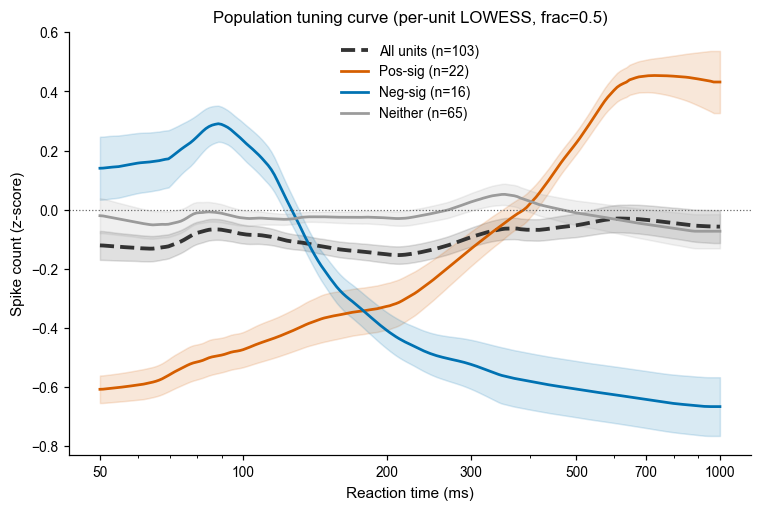

In [13]:
RT_MIN_CURVE, RT_MAX_CURVE = 0.05, 1.0
LOWESS_FRAC  = 0.5   # fraction of trials used per local fit; increase for smoother
N_GRID       = 200   # evaluation grid points in log-RT space
MIN_TRIALS   = 20    # skip units with fewer usable trials

df_curve = (
    all_counts_df
    .dropna(subset=["reaction_time_firstmove", "spike_count"])
    .query("reaction_time_firstmove >= @RT_MIN_CURVE and reaction_time_firstmove <= @RT_MAX_CURVE and reaction_time_firstmove > 0")
    .copy()
)
df_curve["log_rt"]         = np.log(df_curve["reaction_time_firstmove"])
df_curve["session_prefix"] = df_curve["session"].map(get_session_prefix)
df_curve["unit_canon"]     = df_curve["unit_id"].apply(
    lambda x: str(int(float(x))) if pd.notna(x) else str(x)
)

# Z-score spike counts per unit
u_stats = df_curve.groupby(["session_prefix", "unit_canon"])["spike_count"].agg(["mean", "std"])
df_curve = df_curve.join(
    u_stats.rename(columns={"mean": "_u_mean", "std": "_u_std"}),
    on=["session_prefix", "unit_canon"]
)
df_curve["sc_z"] = (
    (df_curve["spike_count"] - df_curve["_u_mean"])
    / df_curve["_u_std"].replace(0, np.nan)
)

# Fixed evaluation grid in log-RT space
log_rt_grid = np.linspace(np.log(RT_MIN_CURVE), np.log(RT_MAX_CURVE), N_GRID)
rt_grid     = np.exp(log_rt_grid)

# Per-unit LOWESS fits, evaluated on common grid
unit_curves = {}
for (sp, u), g in df_curve.groupby(["session_prefix", "unit_canon"]):
    g = g.dropna(subset=["log_rt", "sc_z"])
    if len(g) < MIN_TRIALS:
        continue
    fitted = sm_lowess(g["sc_z"].values, g["log_rt"].values,
                       frac=LOWESS_FRAC, return_sorted=True)
    unit_curves[(sp, u)] = np.interp(log_rt_grid, fitted[:, 0], fitted[:, 1])

curves_df = pd.DataFrame(unit_curves).T
curves_df.index = pd.MultiIndex.from_tuples(curves_df.index,
                                             names=["session_prefix", "unit"])

# Attach OLS significance group
r_main = results["ols_rt_response"].stats.copy()
r_main["group"] = "neither"
r_main.loc[(r_main["q"] < 0.05) & (r_main["coef"] > 0), "group"] = "pos_sig"
r_main.loc[(r_main["q"] < 0.05) & (r_main["coef"] < 0), "group"] = "neg_sig"
group_map = r_main.set_index(["session_prefix", "unit"])["group"]
curves_df["group"] = curves_df.index.map(lambda idx: group_map.get(idx, "neither"))

grid_cols = [c for c in curves_df.columns if c != "group"]

groups = [
    {"mat": curves_df[grid_cols],                                        "color": PALETTE["all"],     "label": "All units",  "ls": "--", "lw": 2.5},
    {"mat": curves_df.loc[curves_df["group"] == "pos_sig", grid_cols],  "color": PALETTE["pos"],     "label": "Pos-sig",    "lw": 1.8},
    {"mat": curves_df.loc[curves_df["group"] == "neg_sig", grid_cols],  "color": PALETTE["neg"],     "label": "Neg-sig",    "lw": 1.8},
    {"mat": curves_df.loc[curves_df["group"] == "neither", grid_cols],  "color": PALETTE["not_sig"], "label": "Neither",    "lw": 1.8},
]
fig, ax = tuning_band(
    rt_grid, groups,
    title=f"Population tuning curve (per-unit LOWESS, frac={LOWESS_FRAC})",
)
save_fig(fig, "tuning_curve_all", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 10. Early vs late window classification

Motivated by the window sweep above, which shows that encoding prevalence
differs between narrow early [0.05, 0.30 s] and broad late [0.15, 1.00 s]
RT windows. Here we classify units across **all** sign × window combinations
in an unbiased 3×3 framework (neg_sig / not_sig / pos_sig in each window),
then test which categories are enriched beyond the FDR-alpha null.


In [14]:
EARLY_QUERY = "reaction_time_firstmove >= 0.05 and reaction_time_firstmove <= 0.30"
LATE_QUERY  = "reaction_time_firstmove >= 0.15 and reaction_time_firstmove <= 1.00"

spec_early = AnalysisSpec(
    name="_early",
    predictor_col="reaction_time_firstmove",
    response_col="spike_count",
    method="ols",
    trial_query=EARLY_QUERY,
    log_x=True, zscore_x=True,
)
spec_late = AnalysisSpec(
    name="_late",
    predictor_col="reaction_time_firstmove",
    response_col="spike_count",
    method="ols",
    trial_query=LATE_QUERY,
    log_x=True, zscore_x=True,
)

with contextlib.redirect_stdout(io.StringIO()):
    res_early = fit_encoding(all_counts_df, spec_early)
    res_late  = fit_encoding(all_counts_df, spec_late)

def classify_signs(result, alpha=0.05):
    """Map each unit to -1 (neg_sig), 0 (not_sig), or +1 (pos_sig)."""
    r = result.stats.dropna(subset=["T"]).copy()
    r["sign"] = 0
    r.loc[(r["q"] < alpha) & (r["coef"] < 0), "sign"] = -1
    r.loc[(r["q"] < alpha) & (r["coef"] > 0), "sign"] = 1
    return r.set_index(["session_prefix", "unit"])["sign"]

sign_early = classify_signs(res_early)
sign_late  = classify_signs(res_late)

# Align on units present and valid in both fits
combined = (
    sign_early.rename("early").to_frame()
    .join(sign_late.rename("late"), how="inner")
)

# Backward-compatible sets for downstream tuning curve cells
neg_early_units = set(combined.index[combined["early"] == -1])
pos_late_units  = set(combined.index[combined["late"]  ==  1])
overlap_units   = neg_early_units & pos_late_units

n_units = len(combined)
print(f"Units classified (valid in both fits): {n_units}")
print()
print("Early window sign counts:")
print(combined["early"].value_counts().rename({-1:"neg_sig", 0:"not_sig", 1:"pos_sig"}).sort_index())
print()
print("Late window sign counts:")
print(combined["late"].value_counts().rename({-1:"neg_sig", 0:"not_sig", 1:"pos_sig"}).sort_index())


Units classified (valid in both fits): 88

Early window sign counts:
early
neg_sig    17
not_sig    68
pos_sig     3
Name: count, dtype: int64

Late window sign counts:
late
neg_sig     3
not_sig    70
pos_sig    15
Name: count, dtype: int64


Chi-square test (early × late independence): chi2=9.15  df=4  p=5.757e-02
  [note] some expected counts < 5 — chi-square approximation may be imprecise

Binomial tests vs FDR-alpha null (expected ≤4.4 sig by chance):
  neg_early        n= 17  p=1.540e-06  ***
  pos_early        n=  3  p=8.221e-01  ns
  neg_late         n=  3  p=8.221e-01  ns
  pos_late         n= 15  p=2.994e-05  ***
  neg/neg          n=  2  p=9.383e-01  ns
  pos/pos          n=  0  p=1.000e+00  ns
  neg_e/pos_l      n=  0  p=1.000e+00  ns
  pos_e/neg_l      n=  0  p=1.000e+00  ns


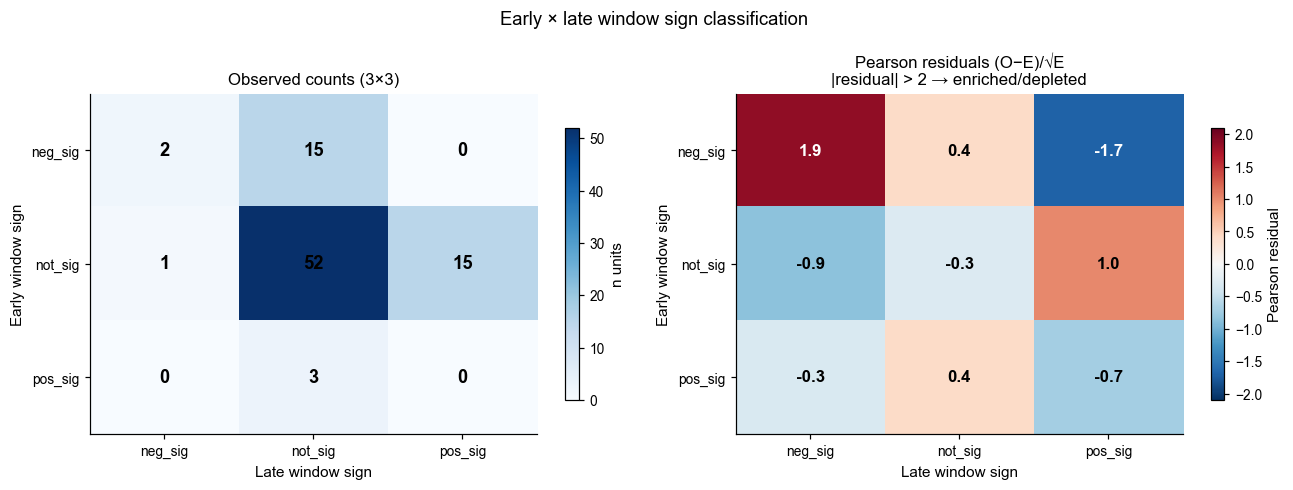

In [15]:
from scipy.stats import chi2_contingency, binomtest

fdr_alpha   = spec_early.fdr_alpha
sign_vals   = [-1, 0, 1]
sign_labels = {-1: "neg_sig", 0: "not_sig", 1: "pos_sig"}

# 3×3 contingency table
table_3x3 = pd.crosstab(combined["early"], combined["late"])
for s in sign_vals:
    if s not in table_3x3.index:   table_3x3.loc[s] = 0
    if s not in table_3x3.columns: table_3x3[s] = 0
table_3x3 = table_3x3.loc[sign_vals, sign_vals]

# Chi-square test — drop all-zero rows/cols before testing
tbl_trim = table_3x3.loc[
    table_3x3.sum(axis=1) > 0,
    table_3x3.sum(axis=0) > 0,
]
try:
    chi2, p_chi2, dof, expected_trim = chi2_contingency(tbl_trim.values)
    expected = pd.DataFrame(0.0, index=sign_vals, columns=sign_vals)
    expected.loc[tbl_trim.index, tbl_trim.columns] = expected_trim
    expected = expected.values
    print(f"Chi-square test (early × late independence): "
          f"chi2={chi2:.2f}  df={dof}  p={p_chi2:.3e}")
    if expected_trim.min() < 5:
        print("  [note] some expected counts < 5 — chi-square approximation may be imprecise")
except ValueError as e:
    print(f"Chi-square could not be computed: {e}")
    expected = np.full((3, 3), n_units / 9)
    chi2, p_chi2 = np.nan, np.nan
print()

pearson_resid = (table_3x3.values - expected) / np.sqrt(np.maximum(expected, 1e-9))

# Binomial tests for each meaningful category
cats = {
    "neg_early":   ((combined["early"] == -1)).sum(),
    "pos_early":   ((combined["early"] ==  1)).sum(),
    "neg_late":    ((combined["late"]  == -1)).sum(),
    "pos_late":    ((combined["late"]  ==  1)).sum(),
    "neg/neg":     ((combined["early"] == -1) & (combined["late"] == -1)).sum(),
    "pos/pos":     ((combined["early"] ==  1) & (combined["late"] ==  1)).sum(),
    "neg_e/pos_l": ((combined["early"] == -1) & (combined["late"] ==  1)).sum(),
    "pos_e/neg_l": ((combined["early"] ==  1) & (combined["late"] == -1)).sum(),
}
expected_n = fdr_alpha * n_units
print(f"Binomial tests vs FDR-alpha null (expected ≤{expected_n:.1f} sig by chance):")
for cat, n in cats.items():
    bt = binomtest(int(n), n_units, fdr_alpha, alternative="greater")
    stars = "***" if bt.pvalue < 0.001 else ("**" if bt.pvalue < 0.01 else ("*" if bt.pvalue < 0.05 else "ns"))
    print(f"  {cat:15s}  n={int(n):3d}  p={bt.pvalue:.3e}  {stars}")

fig, axes = sign_contingency(table_3x3, pearson_resid)
save_fig(fig, "sign_contingency_3x3", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 10b. Focused analysis: neg-sig early and pos-sig late

From the unbiased classification above, **neg-sig early** and **pos-sig late**
emerge as the most enriched off-diagonal categories (positive Pearson residuals).
These represent complementary RT-encoding populations:
- **Neg-sig early** [0.05–0.30 s]: more spikes before fast licks
- **Pos-sig late** [0.15–1.00 s]: more spikes before slow licks

The sign-flip pattern (neg in early, pos in late) implies non-monotone tuning
that a single global linear fit misses. Below we characterize their tuning curves
and test whether each category is enriched beyond chance.

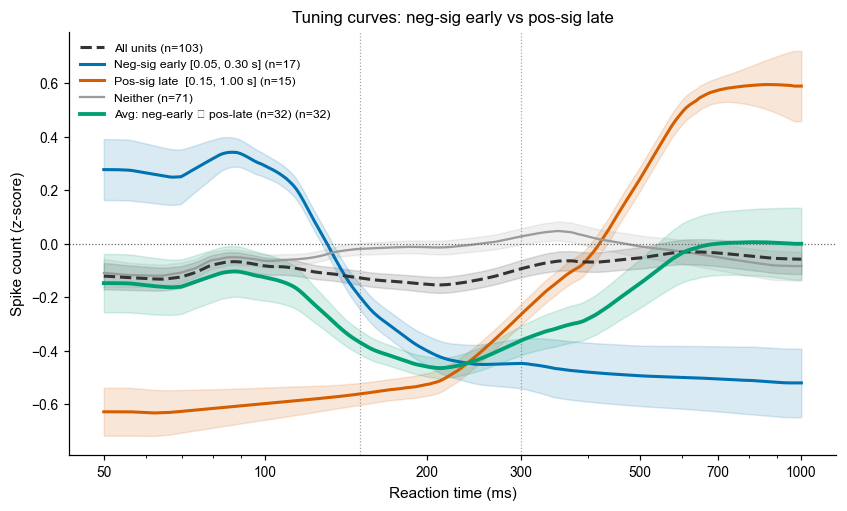

In [16]:
def get_group(sp_u):
    in_neg = sp_u in neg_early_units
    in_pos = sp_u in pos_late_units
    if in_neg and in_pos: return "both"
    if in_neg:            return "neg_early"
    if in_pos:            return "pos_late"
    return "neither"

curves_df2 = curves_df[grid_cols].copy()
curves_df2["group"] = [get_group(idx) for idx in curves_df2.index]

mat_neg   = curves_df2.loc[curves_df2["group"] == "neg_early", grid_cols]
mat_pos   = curves_df2.loc[curves_df2["group"] == "pos_late",  grid_cols]
mat_both  = curves_df2.loc[curves_df2["group"] == "both",      grid_cols]
mat_none  = curves_df2.loc[curves_df2["group"] == "neither",   grid_cols]
mat_union = curves_df2.loc[curves_df2["group"].isin(["neg_early", "pos_late", "both"]), grid_cols]

groups = [
    {"mat": curves_df[grid_cols],          "color": PALETTE["all"],     "label": "All units",                       "ls": "--", "lw": 2, "zorder": 5},
    {"mat": mat_neg,                        "color": PALETTE["neg"],     "label": "Neg-sig early [0.05, 0.30 s]",   "lw": 2},
    {"mat": mat_pos,                        "color": PALETTE["pos"],     "label": "Pos-sig late  [0.15, 1.00 s]",   "lw": 2},
    {"mat": mat_both,                       "color": PALETTE["accent"],  "label": "Both",                           "lw": 2},
    {"mat": mat_none,                       "color": PALETTE["not_sig"], "label": "Neither",                        "lw": 1.5},
]
if len(mat_union):
    groups.append({
        "mat": mat_union, "color": OKABE_ITO["bluish_green"],
        "label": f"Avg: neg-early ∪ pos-late (n={len(mat_union)})",
        "lw": 2.5, "zorder": 6,
    })

fig, ax = tuning_band(
    rt_grid, groups, vlines=[0.15, 0.30],
    title="Tuning curves: neg-sig early vs pos-sig late",
    figsize=(9, 5),
)
ax.legend(fontsize=8, loc="upper left")
save_fig(fig, "tuning_curve_early_late", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 11. Response vs baseline

Compare T-stats between the response window (0–200 ms post-cue) and the
pre-cue baseline (-1 to 0 s). Units with response encoding but not baseline
encoding are of primary interest.

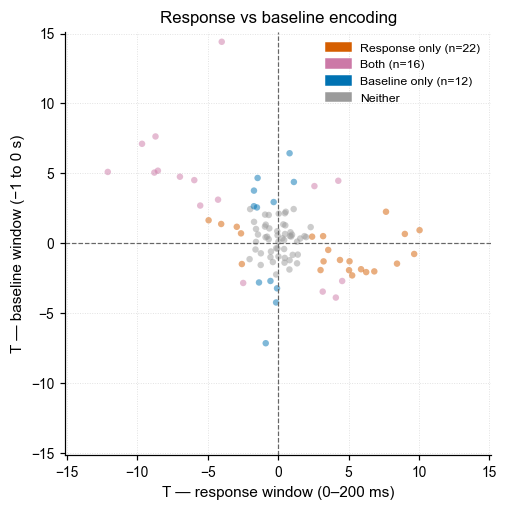

In [17]:
from matplotlib.patches import Patch

r_resp = results["ols_rt_response"].stats.set_index(["session_prefix","unit"])[["T","sig_fdr"]].rename(columns={"T":"T_response","sig_fdr":"sig_response"})
r_base = results["ols_rt_baseline"].stats.set_index(["session_prefix","unit"])[["T","sig_fdr"]].rename(columns={"T":"T_baseline","sig_fdr":"sig_baseline"})
rb = r_resp.join(r_base, how="inner").dropna()

n_resp_only = int((rb["sig_response"] & ~rb["sig_baseline"]).sum())
n_base_only = int((~rb["sig_response"] & rb["sig_baseline"]).sum())
n_both      = int((rb["sig_response"] & rb["sig_baseline"]).sum())

colors = np.where(rb["sig_response"] & ~rb["sig_baseline"], PALETTE["pos"],
         np.where(rb["sig_response"] &  rb["sig_baseline"], PALETTE["accent"],
         np.where(~rb["sig_response"] & rb["sig_baseline"], PALETTE["neg"],
                  PALETTE["not_sig"])))

fig, ax = t_scatter(
    rb["T_response"], rb["T_baseline"],
    xlabel="T — response window (0–200 ms)",
    ylabel="T — baseline window (−1 to 0 s)",
    title="Response vs baseline encoding",
    c=colors, diagonal="crosshair",
)
ax.legend(handles=[
    Patch(color=PALETTE["pos"],     label=f"Response only (n={n_resp_only})"),
    Patch(color=PALETTE["accent"],  label=f"Both (n={n_both})"),
    Patch(color=PALETTE["neg"],     label=f"Baseline only (n={n_base_only})"),
    Patch(color=PALETTE["not_sig"], label="Neither"),
], fontsize=8)
save_fig(fig, "response_vs_baseline", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 12. Poisson GLM encoding

Poisson GLM: `spike_count ~ 1 + log(RT)`, per unit. Compared against OLS T-stats.
The GLM accounts for the count-data nature of spike responses (non-negative integers,
variance proportional to mean). Coefficient is on the log scale: change in
log(mean spike count) per SD of log(RT).

[glm_poisson_rt] 103 units, 103 valid, sig: +15 / -12 (FDR α=0.05)
AnalysisResult('glm_poisson_rt': 103 units, sig +15/-12)


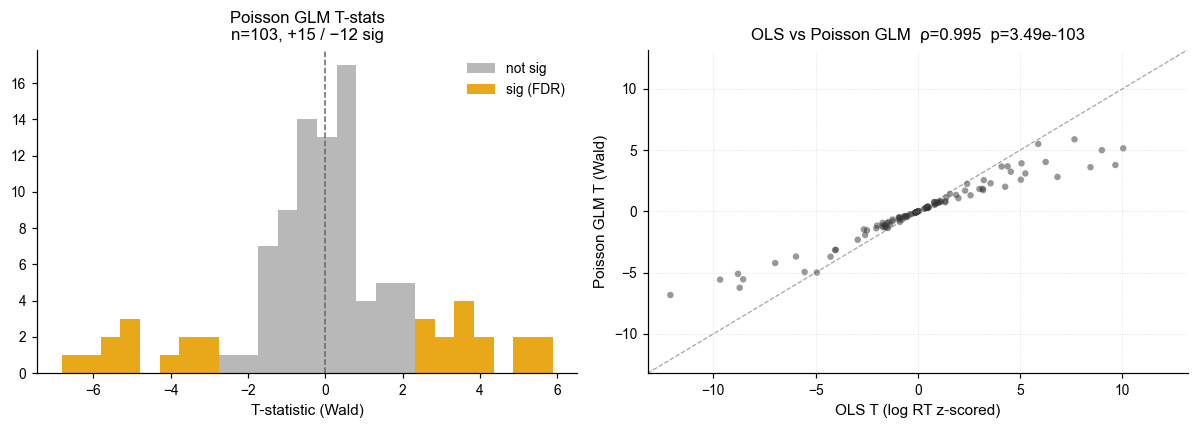

In [18]:
from scipy.stats import spearmanr as _spearmanr

spec_glm = AnalysisSpec(
    name="glm_poisson_rt",
    predictor_col="reaction_time_firstmove",
    response_col="spike_count",
    method="glm",
    glm_family="poisson",
    trial_query=RT_QUERY,
    log_x=True, zscore_x=True,
    notes="Poisson GLM: log(mean spike count) ~ log(RT) z-scored",
)

res_glm = fit_encoding(all_counts_df, spec_glm)
reg.register(res_glm)
print(res_glm)

t_ols = results["ols_rt_response"].stats.set_index(["session_prefix", "unit"])["T"]
t_glm = res_glm.stats.set_index(["session_prefix", "unit"])["T"]
cmp = t_ols.rename("T_ols").to_frame().join(t_glm.rename("T_glm"), how="inner").dropna()
rho, p_rho = _spearmanr(cmp["T_ols"], cmp["T_glm"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tstat_hist(res_glm.stats, name="Poisson GLM T-stats", xlabel="T-statistic (Wald)", ax=axes[0])
t_scatter(
    cmp["T_ols"], cmp["T_glm"],
    xlabel="OLS T (log RT z-scored)", ylabel="Poisson GLM T (Wald)",
    title=f"OLS vs Poisson GLM  ρ={rho:.3f}  p={p_rho:.2e}",
    ax=axes[1],
)
plt.tight_layout()
save_fig(fig, "ols_vs_glm", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 12b. GLM diagnostic: mean-variance and residuals

Two checks for where Poisson specification matters over OLS:

1. **Mean-variance**: for Poisson-distributed counts, variance ≈ mean across units. Points above the line indicate overdispersion — the degree of which determines whether OLS is misspecified.
2. **Residuals vs fitted**: OLS residuals fan with fitted value if the Poisson mean-variance relationship holds (heteroscedasticity). GLM Pearson residuals — standardized by `√(fitted)` — should be flat across the range.

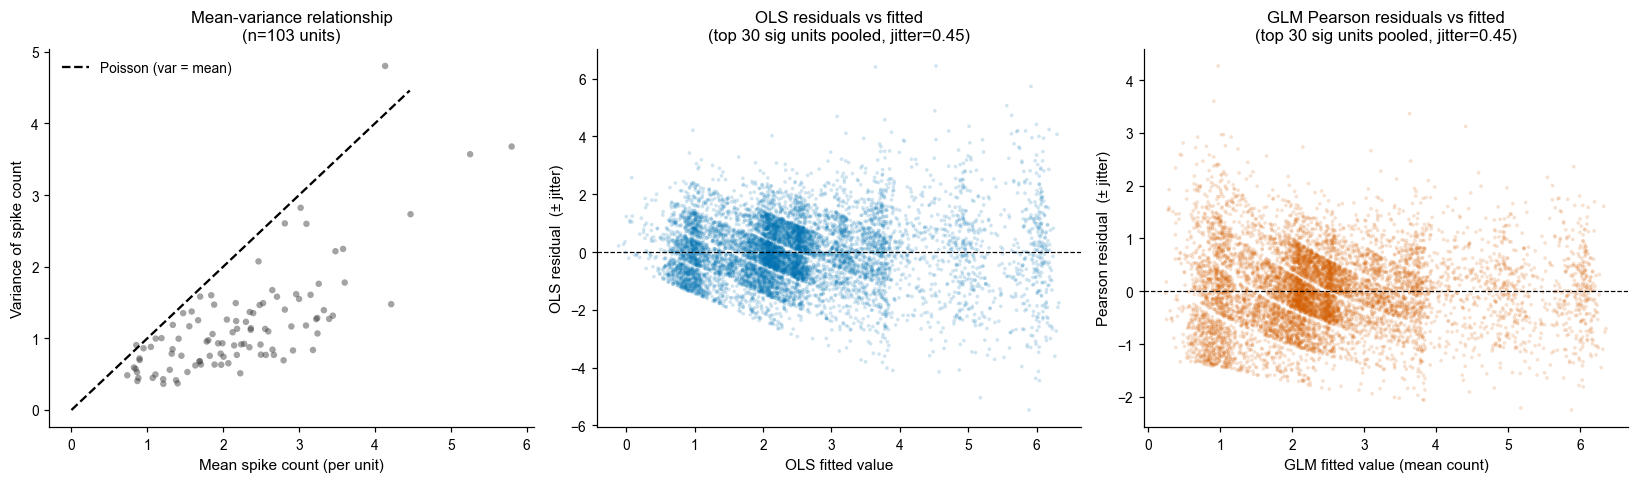

In [19]:
import statsmodels.api as sm_api

N_DIAG       = 30    # sig units to include in residual panels
JITTER_SCALE = 0.45  # uniform y-jitter (visualization only)

rng = np.random.default_rng(42)

# ── 1. Mean-variance per unit ───────────────────────────────────────────────
mv = (df_curve
      .groupby(["session_prefix", "unit_canon"])["spike_count"]
      .agg(["mean", "var", "count"])
      .query("count >= @MIN_TRIALS")
      .dropna())

# ── 2. Re-fit OLS + GLM for top sig units, collect residuals ────────────────
sig_units = (
    results["ols_rt_response"].stats
    .loc[results["ols_rt_response"].stats["sig_fdr"]]
    .assign(absT=lambda d: d["T"].abs())
    .sort_values("absT", ascending=False)
    .head(N_DIAG)
    [["session_prefix", "unit"]]
)

ols_recs, glm_recs = [], []
for _, row in sig_units.iterrows():
    sp, u = row["session_prefix"], row["unit"]
    g = df_curve[
        (df_curve["session_prefix"] == sp) & (df_curve["unit_canon"] == u)
    ].dropna(subset=["log_rt", "spike_count"])
    if len(g) < MIN_TRIALS:
        continue
    mu_x, sd_x = g["log_rt"].mean(), g["log_rt"].std()
    if sd_x < 1e-9:
        continue
    X = sm_api.add_constant((g["log_rt"].values - mu_x) / sd_x)
    y = g["spike_count"].values.astype(float)
    j = rng.uniform(-JITTER_SCALE, JITTER_SCALE, size=len(y))
    try:
        ols = sm_api.OLS(y, X).fit()
        ols_recs.append(pd.DataFrame({"fitted": ols.fittedvalues, "resid": ols.resid + j}))
    except Exception:
        pass
    try:
        glm = sm_api.GLM(y.astype(int), X, family=sm_api.families.Poisson()).fit()
        glm_recs.append(pd.DataFrame({
            "fitted":        glm.fittedvalues,
            "resid_pearson": glm.resid_pearson + j / np.sqrt(np.maximum(glm.fittedvalues, 1e-6)),
        }))
    except Exception:
        pass

ols_all = pd.concat(ols_recs, ignore_index=True) if ols_recs else pd.DataFrame()
glm_all = pd.concat(glm_recs, ignore_index=True) if glm_recs else pd.DataFrame()

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.scatter(mv["mean"], mv["var"], s=18, alpha=0.45, edgecolors="none", color=PALETTE["all"])
x_line = np.linspace(0, mv["mean"].quantile(0.98), 200)
ax.plot(x_line, x_line, "k--", lw=1.5, label="Poisson (var = mean)")
ax.set_xlabel("Mean spike count (per unit)")
ax.set_ylabel("Variance of spike count")
ax.set_title(f"Mean-variance relationship\n(n={len(mv)} units)")
ax.legend()
style_ax(ax)

ax = axes[1]
if len(ols_all):
    ax.scatter(ols_all["fitted"], ols_all["resid"],
               s=6, alpha=0.18, edgecolors="none", color=PALETTE["neg"])
    ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("OLS fitted value")
ax.set_ylabel("OLS residual  (± jitter)")
ax.set_title(f"OLS residuals vs fitted\n(top {N_DIAG} sig units pooled, jitter={JITTER_SCALE})")
style_ax(ax)

ax = axes[2]
if len(glm_all):
    ax.scatter(glm_all["fitted"], glm_all["resid_pearson"],
               s=6, alpha=0.18, edgecolors="none", color=PALETTE["pos"])
    ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("GLM fitted value (mean count)")
ax.set_ylabel("Pearson residual  (± jitter)")
ax.set_title(f"GLM Pearson residuals vs fitted\n(top {N_DIAG} sig units pooled, jitter={JITTER_SCALE})")
style_ax(ax)

plt.tight_layout()
save_fig(fig, "glm_diagnostic", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()